In [1]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
from diffPLOG2TROE.rate_constants import FallOff
from diffPLOG2TROE.physical_constants import constants
from diffPLOG2TROE.stoichiometry import extract_stoichiometry, latexify_reaction

In [2]:
stoich = extract_stoichiometry("H+O2(+M)=HO2(+M)")
print(latexify_reaction("H+O2(+M)=HO2(+M)"))
print(stoich)

\ce{ 1.0H + 1.0O2 ( + M) = 1.0HO2 (+ M) }
{'reactants': {'H': 1.0, 'O2': 1.0}, 'products': {'HO2': 1.0}}


1.87759e+11  units: mol, cm3, s


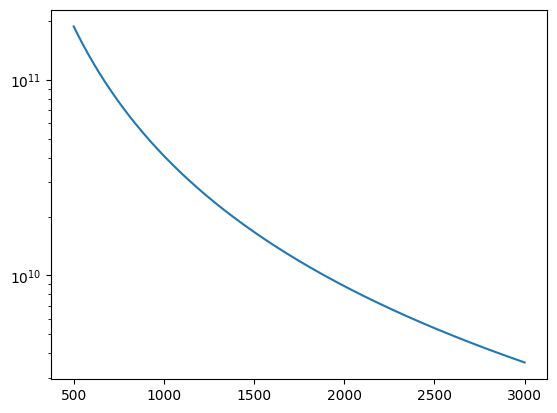

In [3]:
troe_constant = {
    "name": "H+O2(+M)=HO2(+M)",
    "type": "falloff",
    "falloff-type": "troe",
    "rate-constant": {
        "lpl-coefficients": [1.74e+19, -1.230, 0.000],
        "hpl-coefficients": [4.6500e+12, 0.440, 0.000],
        "falloff-coefficients": [0.670000, 1.000e-30, 1.000e+30, 1.000e+30],
    },
    "efficiencies": {"H2": 1.300, "HE": 0.640, "H2O": 10.000, "AR": 0.500, "CO": 1.900, "CO2": 3.800, "CH4": 2.000, "C2H6": 3.000}
}
troe_constant = FallOff(troe_constant)

T_range = jnp.linspace(500, 3000, 300)
P_range = 1.

k, M = troe_constant.kinetic_constant(T_range, P_range)

print(f"{k[0]:.5e}  units: mol, cm3, s")

plt.semilogy(T_range, k)
plt.show()

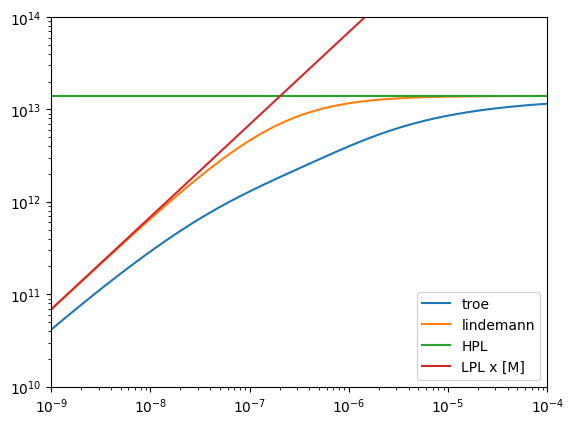

In [4]:
troe_constant = {
    "name": "2CH3(+M)=C2H6(+M)",
    "type": "falloff",
    "falloff-type": "troe",
    "rate-constant": {
        "lpl-coefficients": [3.400E+41, -7.030, 2762.00],
        "hpl-coefficients": [6.770E+16, -1.180, 654.00],
        "falloff-coefficients": [0.619, 73.20, 1180, 9999.00],
    },
}
troe_constant = FallOff(troe_constant)

lindemann_constant = {
    "name": "2CH3(+M)=C2H6(+M)",
    "type": "falloff",
    "falloff-type": "lindemann",
    "rate-constant": {
        "lpl-coefficients": [3.400E+41, -7.030, 2762.00],
        "hpl-coefficients": [6.770E+16, -1.180, 654.00],
    },
}
lindemann_constant = FallOff(lindemann_constant)

T_vec = jnp.array([1000]*300)
P_vec = jnp.logspace(-5, 2, 300, dtype=jnp.float64)
hpl = troe_constant.hpl.kinetic_constant(T_vec)
lpl = troe_constant.lpl.kinetic_constant(T_vec)
k, M = troe_constant.kinetic_constant(T_vec, P_vec)
k_lindemann, _ = lindemann_constant.kinetic_constant(T_vec, P_vec)

fig, ax = plt.subplots()

ax.plot(M[:, 0], k[:, 0], label="troe")
ax.plot(M[:, 0], k_lindemann[:, 0], label="lindemann")
ax.plot(M[:, 0], hpl, label="HPL")
ax.plot(M[:, 0], lpl*M[:, 0], label="LPL x [M]")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([1e-9, 1e-4])
ax.set_ylim([1e10, 1e14])

ax.legend()
plt.show()